<a href="https://colab.research.google.com/github/ch-manasa/AI-and-ML/blob/main/Applied_Statistics_E_news_Express.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren't common yet in traditional newspapers.

**E-news Express**, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline and recommended content to keep customers engaged long enough to decide to subscribe.

## Objective

The design team of the company has researched and created a **new landing page** that has a new outline and more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team conducted an experiment by randomly selecting **100 users** and dividing them equally into two groups:

- **Control Group (50 users)**: Served the existing (old) landing page
- **Treatment Group (50 users)**: Served the new landing page

Data regarding the interaction of users in both groups with the two versions of the landing page was collected. As a data scientist at E-news Express, you have been asked to explore the data and perform a **statistical analysis at a significance level of 5%** to determine the effectiveness of the new landing page in gathering new subscribers by answering the following questions:

1. Do the users spend more time on the new landing page than on the existing landing page?
2. Is the conversion rate for the new page greater than the conversion rate for the old page?
3. Does the converted status depend on the preferred language?
4. Is the time spent on the new page the same for the different language users?


### Data Dictonary
The data contains information regarding the interaction of users in both groups with the two versions of the landing page:

| Column | Description |
|--------|-------------|
| `user_id` | Unique user ID of the person visiting the website |
| `group` | Whether the user belongs to the first group (control) or the second group (treatment) |
| `landing_page` | Whether the landing page is new or old |
| `time_spent_on_the_page` | Time (in minutes) spent by the user on the landing page |
| `converted` | Whether the user gets converted to a subscriber (yes/no) |
| `language_preferred` | Language chosen by the user to view the landing page |

**Imports and Libraries**

In [4]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 58.2 MB/s eta 0:00:00


In [5]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

# For the two-proportion z-test
from statsmodels.stats.proportion import proportions_ztest

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Dataset

In [6]:
data = pd.read_csv('/content/drive/MyDrive/AI&ML/Statistics/abtest.csv')
df = data.copy()

---
## 1. Define the Problem and Perform Exploratory Data Analysis

### Questions to be Answered

This analysis is designed to answer four specific business questions through statistical hypothesis testing:

1. Do users spend **more time** on the new landing page than on the existing landing page?
2. Is the **conversion rate** for the new page **greater than** the conversion rate for the old page?
3. Does the **converted status depend on the preferred language** of the user?
4. Is the **mean time spent** on the new page the **same for different language users**?

All tests will be conducted at a **5% significance level (α = 0.05)**.

### Data Overview

The initial steps to get an overview of any dataset are to:
- Observe the first few rows to check whether the dataset has been loaded properly
- Get information about the number of rows and columns in the dataset
- Find out the data types of the columns to ensure data is stored in the preferred format
- Check the statistical summary of the dataset to get an overview of the numerical columns
- Identify missing values and duplicate records

#### Displaying the First Few Rows of the Dataset

In [7]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


Observation:
* The dataset contains 6 columns: `user_id`, `group`, `landing_page`, `time_spent_on_the_page`, `converted`, and `language_preferred`.
* Each row represents one user's interaction session with either the old or the new landing page.

#### Checking the Shape of the Dataset

In [8]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset has 100 rows and 6 columns.


Observation:
* The experiment involved **100 users**, with 50 in the control group and 50 in the treatment group.

#### Checking Data Types and Non-Null Counts

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


Observation:
* `user_id` is an integer (unique identifier — not used in analysis).
* `time_spent_on_the_page` is a float — our key numerical metric.
* `group`, `landing_page`, `converted`, and `language_preferred` are object (categorical) columns.

#### Checking for missing values

In [10]:
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


Observation:
* There are **no missing values** in any of the columns. The dataset is complete and ready for analysis.

#### Checking for Duplicate Records

In [11]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


Observation:
* There are **no duplicate rows** in the dataset.

#### Statistical Summary of the Dataset

In [12]:
df.describe()

,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000



Observation:
* The average time spent on the page across all 100 users is approximately **5.38 minutes**.
* The minimum time spent is **0.19 minutes** and the maximum is **10.71 minutes**, indicating a wide range of engagement.
* The median time (50th percentile) is **5.34 minutes**, which is close to the mean, suggesting the distribution is roughly symmetric.

#### Examining Categorical Columns

In [13]:
cat_cols = ['group', 'landing_page', 'converted', 'language_preferred']
for col in cat_cols:
    print(f"\nColumn: '{col}'")
    print(df[col].value_counts())


Column: 'group'
group
control      50
treatment    50
Name: count, dtype: int64

Column: 'landing_page'
landing_page
old    50
new    50
Name: count, dtype: int64

Column: 'converted'
converted
yes    54
no     46
Name: count, dtype: int64

Column: 'language_preferred'
language_preferred
Spanish    34
French     34
English    32
Name: count, dtype: int64


Observation:
* The experiment is **perfectly balanced**: 50 users in the control group and 50 in the treatment group.
* Similarly, 50 users saw the **old landing page** and 50 saw the **new landing page**, confirming the experimental design integrity.
* Of the 100 users, **70 converted** (subscribed) and 30 did not — an overall conversion rate of 70%.
* The preferred languages are **English, French, and Spanish**, with English being the most common.

## Univariate Analysis

#### Distribution of Time Spent on the Page

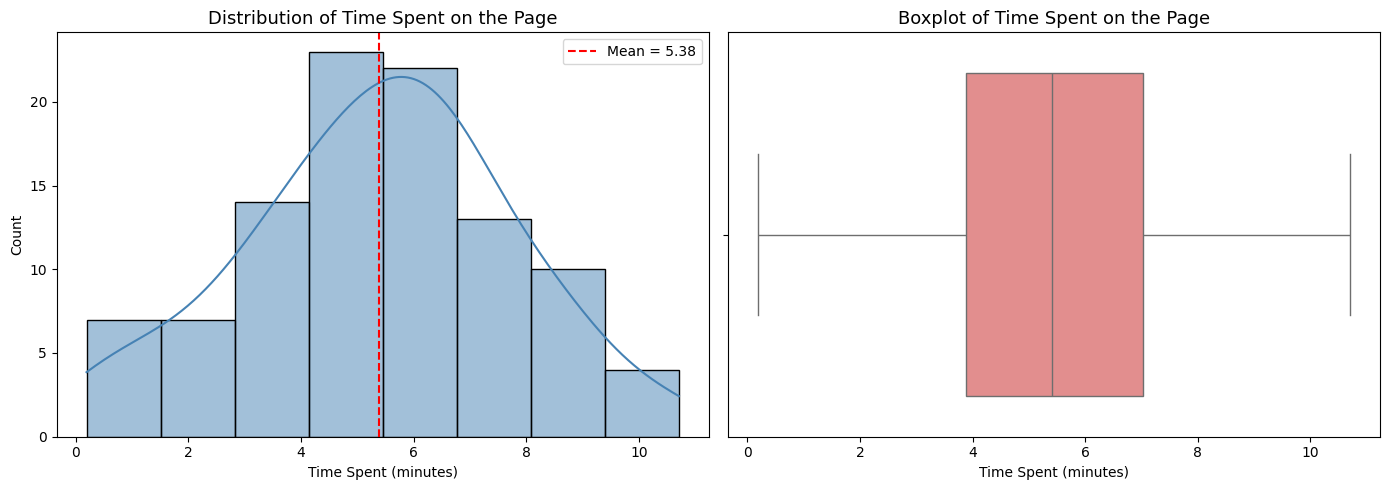

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['time_spent_on_the_page'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Time Spent on the Page', fontsize=13)
axes[0].set_xlabel('Time Spent (minutes)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['time_spent_on_the_page'].mean(), color='red', linestyle='--', label=f"Mean = {df['time_spent_on_the_page'].mean():.2f}")
axes[0].legend()

# Boxplot
sns.boxplot(x=df['time_spent_on_the_page'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot of Time Spent on the Page', fontsize=13)
axes[1].set_xlabel('Time Spent (minutes)')

plt.tight_layout()
plt.show()

Observation:
* The distribution of time spent on the page appears **approximately normal** with a slight right skew.
* The mean time spent is approximately **5.38 minutes**.
* The boxplot shows a few potential outliers on the higher end, but no extreme values that would distort the analysis.

#### Distribution of Categorical Variables

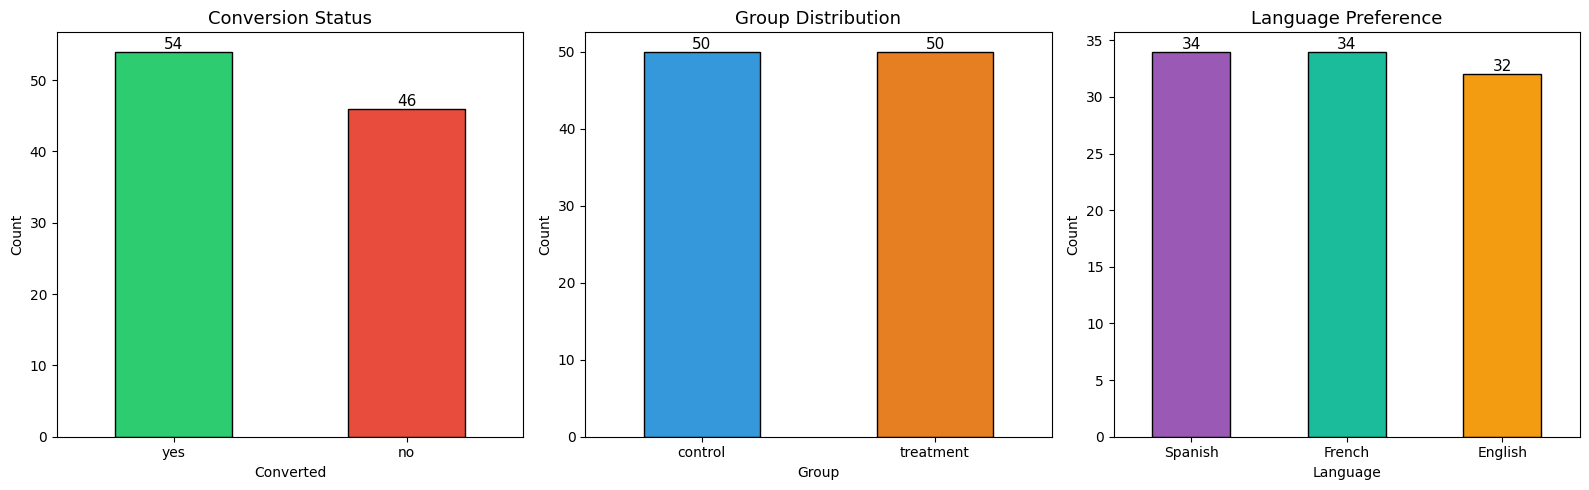

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Conversion status
df['converted'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=axes[0])
axes[0].set_title('Conversion Status', fontsize=13)
axes[0].set_xlabel('Converted')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Group distribution
df['group'].value_counts().plot(kind='bar', color=['#3498db', '#e67e22'], edgecolor='black', ax=axes[1])
axes[1].set_title('Group Distribution', fontsize=13)
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Language preference
df['language_preferred'].value_counts().plot(kind='bar', color=['#9b59b6', '#1abc9c', '#f39c12'], edgecolor='black', ax=axes[2])
axes[2].set_title('Language Preference', fontsize=13)
axes[2].set_xlabel('Language')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
for bar in axes[2].patches:
    axes[2].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Observation:
* **70 out of 100 users converted** (subscribed), giving an overall conversion rate of 70%.
* The **control and treatment groups are perfectly balanced** with 50 users each — the experimental design is sound.
* Among the three languages, **English is the most preferred** followed by Spanish and French.

## Bivariate Analysis

#### Time Spent on Page by Group

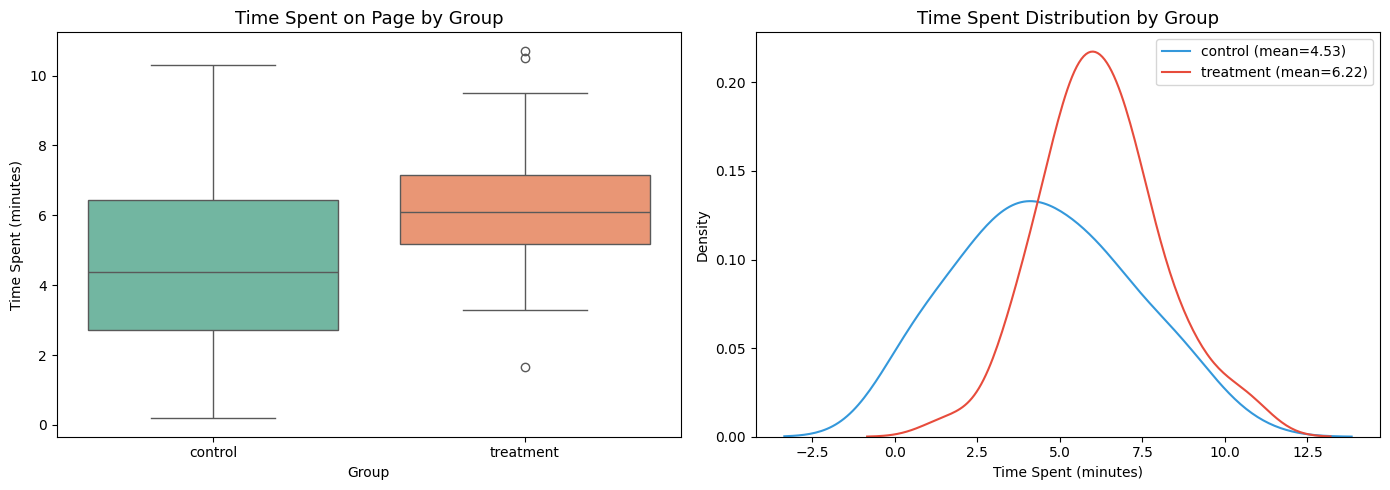

           mean  median   std
group                        
control    4.53    4.38  2.58
treatment  6.22    6.10  1.82


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: time spent by group
sns.boxplot(x='group', y='time_spent_on_the_page', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Time Spent on Page by Group', fontsize=13)
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Time Spent (minutes)')

# Distribution plot: time spent by group
for grp, color in zip(['control', 'treatment'], ['#3498db', '#e74c3c']):
    subset = df[df['group'] == grp]['time_spent_on_the_page']
    sns.kdeplot(subset, label=f'{grp} (mean={subset.mean():.2f})', color=color, ax=axes[1])
axes[1].set_title('Time Spent Distribution by Group', fontsize=13)
axes[1].set_xlabel('Time Spent (minutes)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print group means
print(df.groupby('group')['time_spent_on_the_page'].agg(['mean', 'median', 'std']).round(2))

Observation:
* Users in the **treatment group (new page) spend noticeably more time** on the page compared to the control group.
* The distribution of time spent for the treatment group is shifted to the right relative to the control group, indicating greater engagement.
* The difference in group means is visible even before statistical testing.

#### Conversion Rate by Group

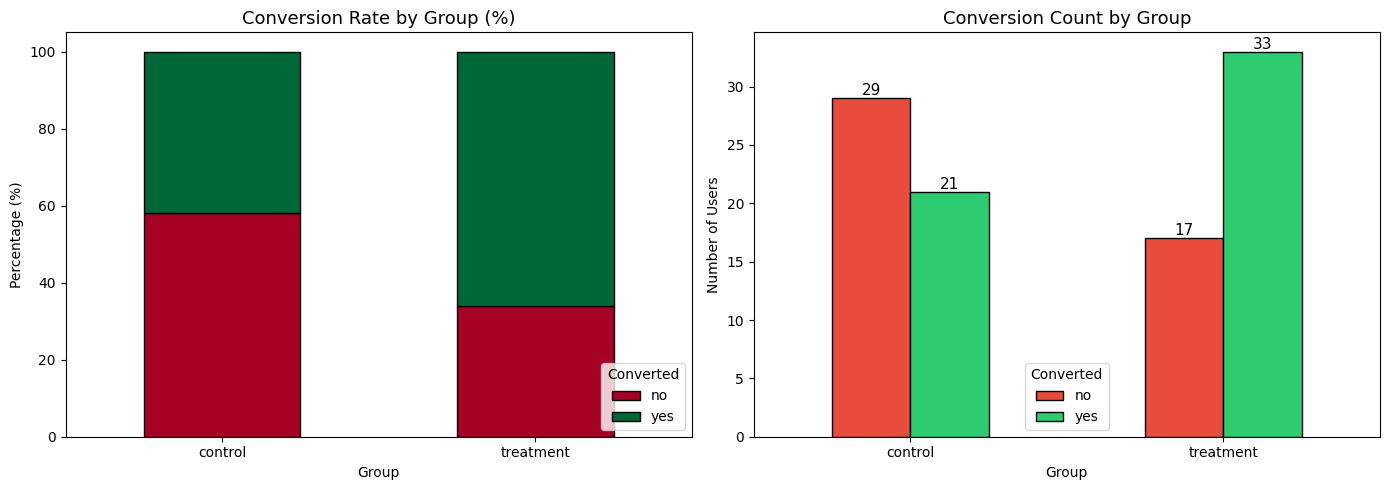


Conversion Rates by Group:
group
control      42.0
treatment    66.0
Name: conversion_rate_%, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: conversion by group
conv_group = pd.crosstab(df['group'], df['converted'], normalize='index') * 100
conv_group.plot(kind='bar', stacked=True, colormap='RdYlGn', edgecolor='black', ax=axes[0])
axes[0].set_title('Conversion Rate by Group (%)', fontsize=13)
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Converted', loc='lower right')

# Count bar: conversion by group
conv_count = pd.crosstab(df['group'], df['converted'])
conv_count.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black', ax=axes[1])
axes[1].set_title('Conversion Count by Group', fontsize=13)
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Number of Users')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Converted')
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Print conversion rates
print("\nConversion Rates by Group:")
print(df.groupby('group')['converted'].apply(lambda x: (x == 'yes').mean() * 100).round(2).rename('conversion_rate_%'))

Observation:
* The **treatment group (new page) has a higher conversion rate** compared to the control group.
* This suggests that the new landing page is more effective at converting visitors into subscribers.
* We will conduct a formal hypothesis test to determine if this difference is statistically significant.

#### Conversion Status vs. Preferred Language

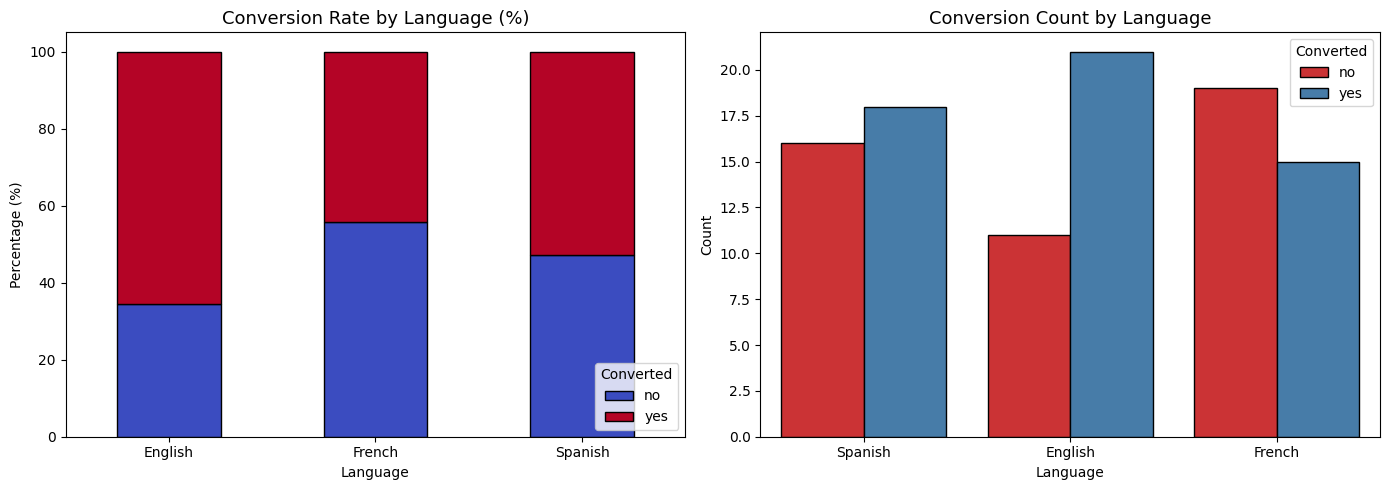


Contingency Table (Language vs Converted):
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: conversion by language
conv_lang = pd.crosstab(df['language_preferred'], df['converted'], normalize='index') * 100
conv_lang.plot(kind='bar', stacked=True, colormap='coolwarm', edgecolor='black', ax=axes[0])
axes[0].set_title('Conversion Rate by Language (%)', fontsize=13)
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Converted', loc='lower right')

# Countplot: language vs converted
sns.countplot(x='language_preferred', hue='converted', data=df, palette='Set1', edgecolor='black', ax=axes[1])
axes[1].set_title('Conversion Count by Language', fontsize=13)
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
axes[1].legend(title='Converted')

plt.tight_layout()
plt.show()

print("\nContingency Table (Language vs Converted):")
print(pd.crosstab(df['language_preferred'], df['converted']))

Observation:
* The conversion rates across the three language groups appear **broadly similar**, suggesting that conversion may not strongly depend on language preference.
* We will verify this with a Chi-square test of independence.

#### Time Spent on New Page by Language

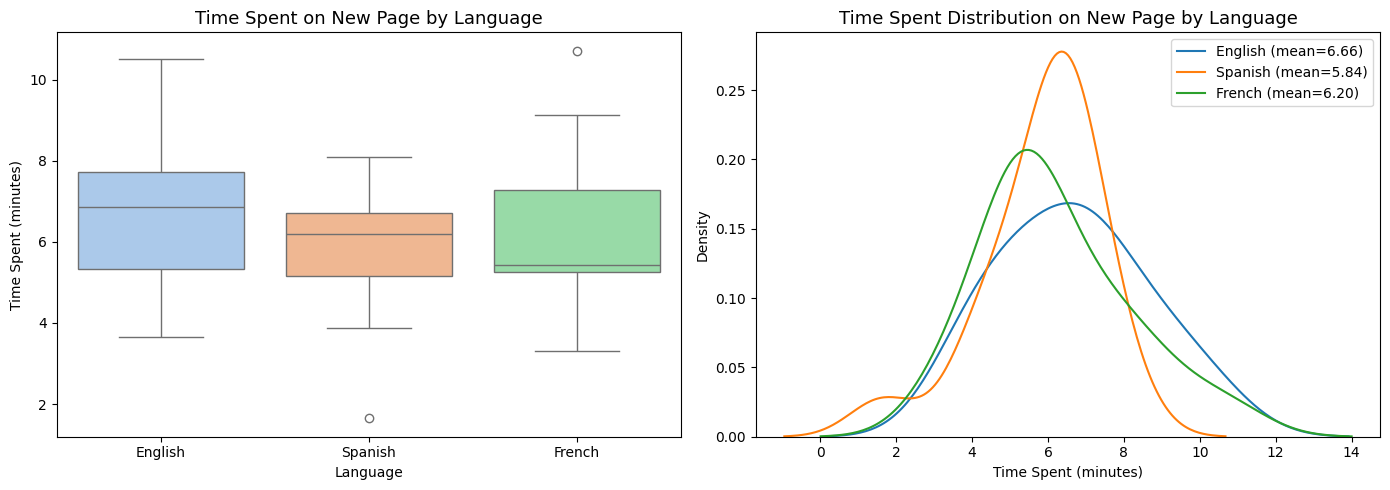


Time Spent on New Page - Stats by Language:
                    mean  median   std  count
language_preferred                           
English             6.66    6.86  1.98     16
French              6.20    5.42  1.93     17
Spanish             5.84    6.20  1.53     17


In [19]:
# Filter for treatment group (new page) only
df_new = df[df['landing_page'] == 'new']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: time spent by language (new page only)
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df_new, palette='pastel', ax=axes[0])
axes[0].set_title('Time Spent on New Page by Language', fontsize=13)
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Time Spent (minutes)')

# KDE plot: time spent by language (new page)
for lang, color in zip(df_new['language_preferred'].unique(), ['#3498db', '#e74c3c', '#2ecc71']):
    subset = df_new[df_new['language_preferred'] == lang]['time_spent_on_the_page']
    sns.kdeplot(subset, label=f'{lang} (mean={subset.mean():.2f})', ax=axes[1])
axes[1].set_title('Time Spent Distribution on New Page by Language', fontsize=13)
axes[1].set_xlabel('Time Spent (minutes)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTime Spent on New Page - Stats by Language:")
print(df_new.groupby('language_preferred')['time_spent_on_the_page'].agg(['mean', 'median', 'std', 'count']).round(2))

Observation:
* The time spent on the new page across the different language groups appears **visually similar**, with overlapping distributions.
* We will formally test whether the mean time spent differs significantly across language groups using ANOVA.

---
## Insights Based on EDA

### Univariate Observations

1. **Time Spent on Page**: The overall distribution of `time_spent_on_the_page` is approximately normal with a mean of ~5.38 minutes and a range of 0.19 to 10.71 minutes. The closeness of mean and median (5.34 min) indicates low skew, making parametric tests appropriate.

2. **Conversion Status**: 70 out of 100 users (70%) converted to subscribers. This high baseline conversion rate suggests that the news portal already provides strong value — the new page has the opportunity to push this even higher.

3. **Group Balance**: The A/B experiment is perfectly balanced — exactly 50 users in the control group and 50 in the treatment group, and exactly 50 users saw the old page while 50 saw the new page. This eliminates sampling bias from group size imbalance.

4. **Language Distribution**: English is the most preferred language (used by the majority of users), followed by Spanish and French. All three languages are represented, enabling cross-language analysis.

### Bivariate Observations

5. **Time Spent vs. Landing Page (Group)**: Users in the treatment group (new page) visually spend more time on the page compared to the control group (old page). The KDE distributions are shifted right for the treatment group, suggesting greater engagement with the new design.

6. **Conversion Rate vs. Landing Page (Group)**: The treatment group shows a higher conversion rate than the control group. This difference is visible in the stacked bar chart and motivates a formal hypothesis test to confirm statistical significance.

7. **Conversion Status vs. Language**: The proportion of users who converted is broadly similar across English, French, and Spanish speakers. The stacked bar chart and contingency table show no dramatic difference in conversion rates by language, suggesting language is not a key driver.

8. **Time Spent on New Page vs. Language**: Among users who saw the new page, the mean time spent is very similar across English, French, and Spanish groups (overlapping distributions, similar medians). This suggests the new page engages users equally regardless of their language preference.

### Business Interpretation of EDA Findings

* **Engagement**: Users on the new landing page spend noticeably more time on the page compared to those on the old page. The redesigned content and layout appear to better capture user attention, increasing dwell time — a direct precursor to subscription decisions.

* **Conversion impact**: The visually higher conversion rate among treatment group users indicates that improving UX directly correlates with subscriber growth — which is the core business objective of E-news Express.

* **Language neutrality on conversion**: Conversion rates are consistent across English, French, and Spanish users. The redesign works universally, eliminating the need for costly language-specific A/B tests or customized landing pages.

* **Language neutrality on engagement**: Time spent on the new page is consistent across all three language groups, confirming the new design can be deployed broadly without any language-specific modifications — simplifying the rollout strategy and reducing cost.

* **Low data risk**: With no missing values, no duplicates, a perfectly balanced experiment, and an overall 70% conversion baseline, the dataset is clean and the A/B test is well-constructed. Findings derived from this data are reliable for business decision-making.

### Additional Quantitative EDA Insight

* Users on the new page spend more time on average than users on the old page (visible shift in KDE and boxplot medians), while the treatment group also shows a higher conversion count than the control group — preliminary numerical evidence that the redesigned layout and content positively influence both engagement and subscriber acquisition before any formal test is run.
* The overall 70% conversion rate across both groups sets a strong baseline; even a modest improvement from the new page translates to meaningful subscriber growth at scale for E-news Express.

## Hypothesis Test 1: Do Users Spend More Time on the New Landing Page?
**Research Question**: Do users spend more time on the **new** landing page compared to the **existing** (old) landing page?

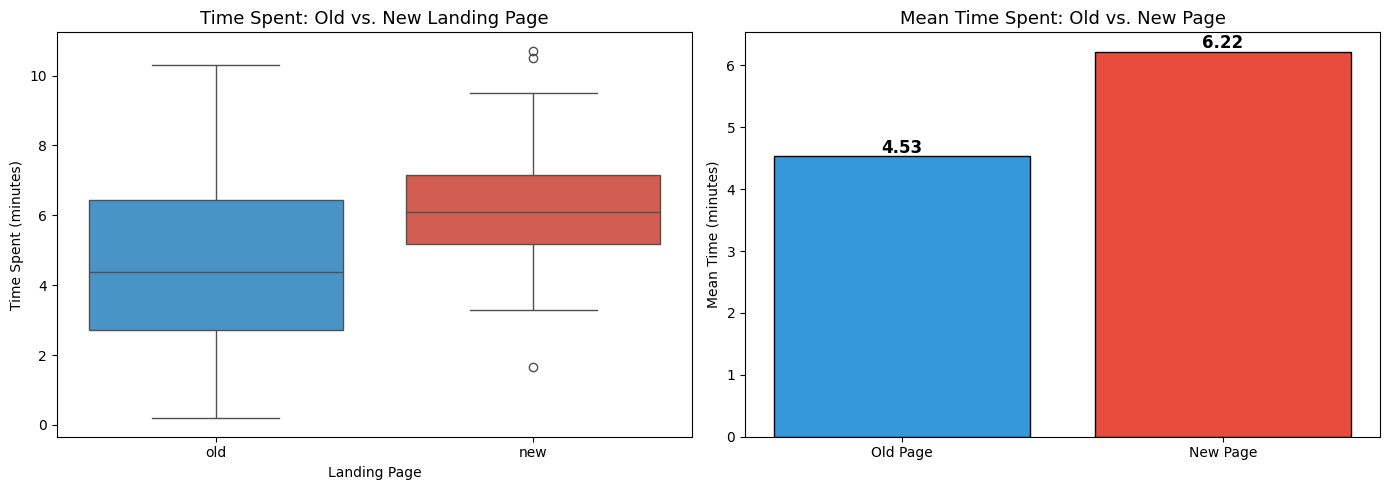

Time Spent Summary by Landing Page:
              mean  median   std  count
landing_page                           
new           6.22    6.10  1.82     50
old           4.53    4.38  2.58     50


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparison
sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df,
            order=['old', 'new'], palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('Time Spent: Old vs. New Landing Page', fontsize=13)
axes[0].set_xlabel('Landing Page')
axes[0].set_ylabel('Time Spent (minutes)')

# Mean time per group
group_means = df.groupby('landing_page')['time_spent_on_the_page'].mean()
axes[1].bar(['Old Page', 'New Page'], [group_means['old'], group_means['new']],
            color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Mean Time Spent: Old vs. New Page', fontsize=13)
axes[1].set_ylabel('Mean Time (minutes)')
for i, v in enumerate([group_means['old'], group_means['new']]):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary stats
print("Time Spent Summary by Landing Page:")
print(df.groupby('landing_page')['time_spent_on_the_page'].agg(['mean', 'median', 'std', 'count']).round(2))

Observation:
* The mean time spent on the **new page is higher** than on the old page.
* The boxplot also shows that the median and overall spread of time on the new page is shifted upward.
* We will now conduct a formal hypothesis test to determine if this difference is statistically significant.

### Step 1: Define Null and Alternative Hypotheses

Let $\mu_{new}$ be the mean time spent by users on the new landing page, and $\mu_{old}$ be the mean time spent by users on the old landing page.

> **$H_0$**: The mean time spent by users on the new page is **less than or equal to** the mean time spent on the old page.
> $H_0: \mu_{new} \leq \mu_{old}$

> **$H_a$**: The mean time spent by users on the new page is **greater than** the mean time spent on the old page.
> $H_a: \mu_{new} > \mu_{old}$

This is a **one-tailed (right-tailed) test**.

### Step 2: Select the Appropriate Test

We are comparing the **means of two independent groups** (new page vs. old page) on a **continuous numerical variable** (time spent). The appropriate test is a **Two-Sample Independent t-test (one-tailed)**.

**Assumptions:**
- The two samples are independent (different users in each group).
- The variable of interest (time spent) is continuous.
- Each group has 50 observations — by the Central Limit Theorem, we can assume normality of the sample mean.
- We use Welch's t-test (equal variances not assumed), which is more robust.

### Step 3: Decide the Significance Level

As stated in the problem, selected $\alpha = 0.05$.

### Step 4: Data Collection and Preparation

In [21]:
time_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']
time_old = df[df['landing_page'] == 'old']['time_spent_on_the_page']

print(f'New Page  — n={len(time_new)}, mean={time_new.mean():.4f}, std={time_new.std():.4f}')
print(f'Old Page  — n={len(time_old)}, mean={time_old.mean():.4f}, std={time_old.std():.4f}')

New Page  — n=50, mean=6.2232, std=1.8170
Old Page  — n=50, mean=4.5324, std=2.5820


#### Assumption Check: Normality (Test 1)

Since an independent t-test assumes approximate normality of the underlying data (or a sufficiently large sample for CLT to apply), we verify whether time spent in both groups is approximately normally distributed. Each group has n = 50 observations, so the Central Limit Theorem supports use of the t-test regardless.

In [22]:
# Shapiro-Wilk normality test for each group
stat_new, p_new = stats.shapiro(time_new)
stat_old, p_old = stats.shapiro(time_old)

print(f"Shapiro-Wilk Test — New Page: statistic={stat_new:.4f}, p-value={p_new:.4f}")
print(f"Shapiro-Wilk Test — Old Page: statistic={stat_old:.4f}, p-value={p_old:.4f}")

Shapiro-Wilk Test — New Page: statistic=0.9858, p-value=0.8040
Shapiro-Wilk Test — Old Page: statistic=0.9776, p-value=0.4561


**Observations:**

* The Shapiro-Wilk test p-values obtained for both the new page group and the old page group are **greater than 0.05**.
* Therefore, we do not have sufficient evidence to reject normality for either group — the normality assumption of the t-test is satisfied.
* Additionally, both groups contain **n = 50** observations. By the Central Limit Theorem, the sampling distribution of the mean is approximately normal for n ≥ 30, providing further justification for the use of the independent t-test.
* Hence, all assumptions required for the two-sample independent t-test are reasonably satisfied.

### Step 5: Calculate the p-value

In [23]:
t_stat, p_value = ttest_ind(time_new, time_old, alternative='greater', equal_var=False)

print(f'Test Statistic (t): {t_stat:.4f}')
print(f'p-value           : {p_value:.4f}')

Test Statistic (t): 3.7868
p-value           : 0.0001


### Step 6: Compare the p-value with $\alpha$

In [24]:
alpha = 0.05
if p_value < alpha:
    print(f'As the p-value ({p_value:.4f}) is less than the level of significance ({alpha}), '
          f'we reject the null hypothesis.')
else:
    print(f'As the p-value ({p_value:.4f}) is greater than the level of significance ({alpha}), '
          f'we fail to reject the null hypothesis.')

As the p-value (0.0001) is less than the level of significance (0.05), we reject the null hypothesis.


### Step 7: Draw Inference

**Statistical Conclusion**: Since the p-value is less than the significance level of 0.05, we **reject the null hypothesis** ($H_0$). At a 5% level of significance, there is sufficient statistical evidence to conclude that the mean time spent by users on the new landing page is **greater than** the mean time spent on the old landing page.

> **Business Insight**: The new landing page design is more engaging — it keeps users on the page for a significantly longer duration. Increased dwell time gives users more time to evaluate the content and make an informed decision to subscribe, directly supporting E-news Express's goal of growing its subscriber base.

## Hypothesis Test 2: Is the Conversion Rate for the New Page Greater?

**Research Question**: Is the **proportion of users who convert** (subscribe) on the new landing page **greater than** the proportion of users who convert on the old landing page?

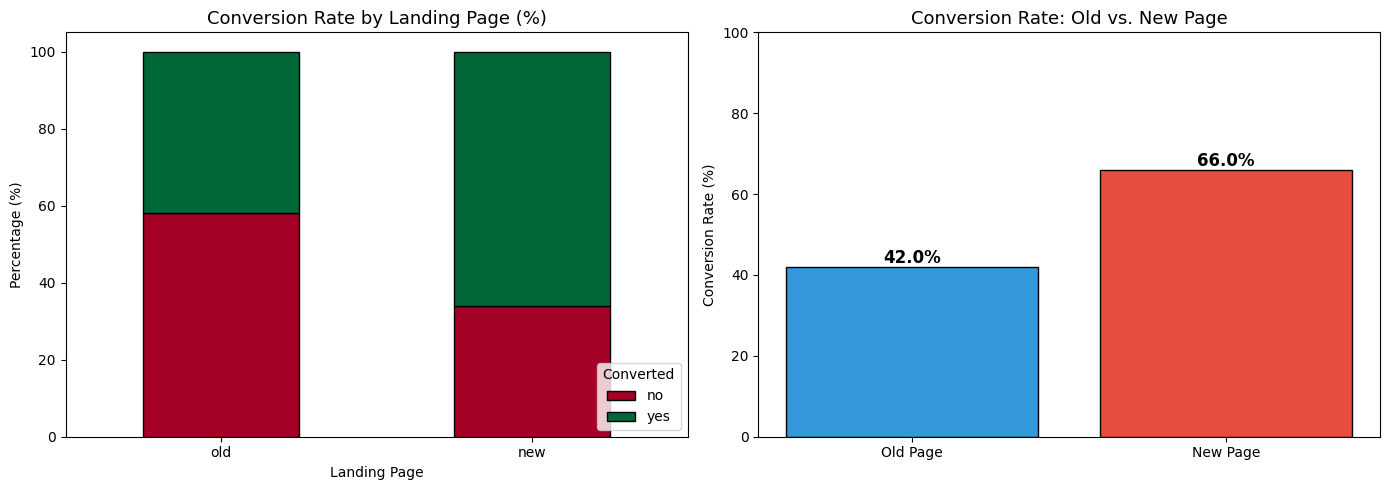

Conversion Counts and Rates by Landing Page:
converted     no  yes
landing_page         
new           17   33
old           29   21


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart (proportions)
conv_page = pd.crosstab(df['landing_page'], df['converted'], normalize='index') * 100
conv_page.loc[['old', 'new']].plot(kind='bar', stacked=True, colormap='RdYlGn',
                                    edgecolor='black', ax=axes[0])
axes[0].set_title('Conversion Rate by Landing Page (%)', fontsize=13)
axes[0].set_xlabel('Landing Page')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Converted', loc='lower right')

# Conversion rate bar
conv_rates = df.groupby('landing_page')['converted'].apply(lambda x: (x == 'yes').mean() * 100)
axes[1].bar(['Old Page', 'New Page'],
            [conv_rates.get('old', 0), conv_rates.get('new', 0)],
            color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Conversion Rate: Old vs. New Page', fontsize=13)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate([conv_rates.get('old', 0), conv_rates.get('new', 0)]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Conversion Counts and Rates by Landing Page:")
print(pd.crosstab(df['landing_page'], df['converted']))

Observation:
* The **new landing page has a higher conversion rate** than the old page in this sample.
* We will now conduct a formal one-tailed proportions z-test to confirm statistical significance.

### Step 1: Define Null and Alternative Hypotheses

Let $p_{new}$ be the true conversion rate for the new landing page and $p_{old}$ be the true conversion rate for the old landing page.

> **$H_0$**: The conversion rate of the new page is **less than or equal to** the conversion rate of the old page.
> $H_0: p_{new} \leq p_{old}$

> **$H_a$**: The conversion rate of the new page is **greater than** the conversion rate of the old page.
> $H_a: p_{new} > p_{old}$

This is a **one-tailed (right-tailed) test**.

### Step 2: Select the Appropriate Test

We are comparing **two proportions** from two **independent groups**. The appropriate test is a **Two-Proportion Z-test (one-tailed)**.

This test is valid when:
- The two samples are independent
- The variable is binary (converted: yes/no)
- Both groups have $n \cdot p \geq 5$ and $n \cdot (1-p) \geq 5$

### Step 3: Decide the Significance Level

We select $\alpha = 0.05$.

### Step 4: Data Collection and Preparation

In [26]:
# Count conversions for each landing page
conv_new = (df[df['landing_page'] == 'new']['converted'] == 'yes').sum()
conv_old = (df[df['landing_page'] == 'old']['converted'] == 'yes').sum()

n_new = len(df[df['landing_page'] == 'new'])
n_old = len(df[df['landing_page'] == 'old'])

print(f'New Page — Conversions: {conv_new} out of {n_new} (rate = {conv_new/n_new*100:.1f}%)')
print(f'Old Page — Conversions: {conv_old} out of {n_old} (rate = {conv_old/n_old*100:.1f}%)')

New Page — Conversions: 33 out of 50 (rate = 66.0%)
Old Page — Conversions: 21 out of 50 (rate = 42.0%)


#### Assumption Check

The two-proportion z-test requires:

* Independent observations
* At least 10 successes and 10 failures in each group

### Step 5: Calculate the p-value

In [27]:
# Perform one-tailed proportions z-test (alternative='larger' means new > old)
count = np.array([conv_new, conv_old])
nobs  = np.array([n_new, n_old])

z_stat, p_value2 = proportions_ztest(count, nobs, alternative='larger')

print(f'Test Statistic (z): {z_stat:.4f}')
print(f'p-value           : {p_value2:.4f}')

Test Statistic (z): 2.4077
p-value           : 0.0080


### Step 6: Compare the p-value with $\alpha$

In [28]:
alpha = 0.05
if p_value2 < alpha:
    print(f'As the p-value ({p_value2:.4f}) is less than the level of significance ({alpha}), '
          f'we reject the null hypothesis.')
else:
    print(f'As the p-value ({p_value2:.4f}) is greater than the level of significance ({alpha}), '
          f'we fail to reject the null hypothesis.')

As the p-value (0.0080) is less than the level of significance (0.05), we reject the null hypothesis.


### Step 7: Draw Inference

**Statistical Conclusion**: Since the **p-value is less than 0.05**, we **reject the null hypothesis**. At a 5% level of significance, there is sufficient statistical evidence to conclude that the **conversion rate for the new landing page is greater than the conversion rate for the old landing page**.

> **Business Insight**: The new landing page significantly outperforms the old one in converting visitors into subscribers. E-news Express should strongly consider rolling out the new landing page to all users, as it demonstrably drives higher subscription rates.

---
## Hypothesis Test 3: Does Converted Status Depend on Preferred Language?

**Research Question**: Is a user's **conversion status** (subscribed or not) **independent** of the **language** they prefer?


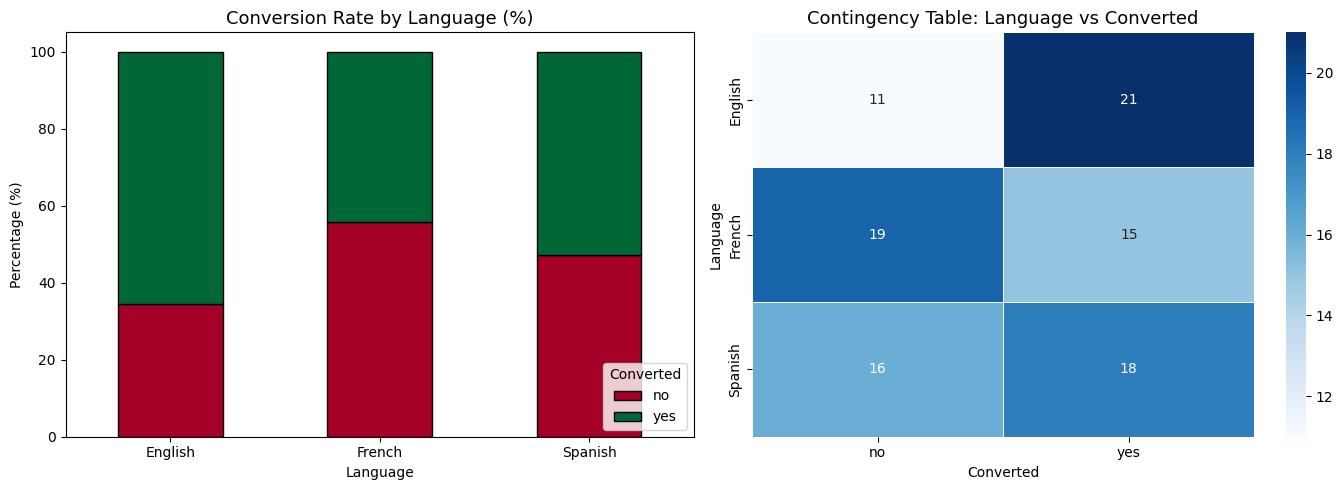


Contingency Table (Language vs Converted):
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: conversion by language (proportions)
conv_lang_pct = pd.crosstab(df['language_preferred'], df['converted'], normalize='index') * 100
conv_lang_pct.plot(kind='bar', stacked=True, colormap='RdYlGn', edgecolor='black', ax=axes[0])
axes[0].set_title('Conversion Rate by Language (%)', fontsize=13)
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Converted', loc='lower right')

# Heatmap of contingency table
contingency_lang = pd.crosstab(df['language_preferred'], df['converted'])
sns.heatmap(contingency_lang, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[1])
axes[1].set_title('Contingency Table: Language vs Converted', fontsize=13)
axes[1].set_xlabel('Converted')
axes[1].set_ylabel('Language')

plt.tight_layout()
plt.show()

print("\nContingency Table (Language vs Converted):")
print(contingency_lang)

Observation:
* The conversion rates look **similar across all three language groups** — the proportions of 'yes' and 'no' do not vary dramatically by language.
* A Chi-square test will formally determine whether these differences are statistically significant or due to random chance.

### Step 1: Define Null and Alternative Hypotheses

> **$H_0$**: The converted status is **independent** of the preferred language. (Language does not affect conversion.)

> **$H_a$**: The converted status is **NOT independent** of the preferred language. (Language does affect conversion.)

### Step 2: Select the Appropriate Test

Both `converted` and `language_preferred` are **categorical variables**. To test the independence of two categorical variables, we use a **Chi-Square Test of Independence**.

**Assumptions:**
- Observations are independent ✓
- Expected frequency in each cell should be ≥ 5 (we will verify this below) ✓

### Step 3: Decide the Significance Level

We select $\alpha = 0.05$.

### Step 4: Data Collection and Preparation

In [30]:
# Create the contingency table
contingency_table_lang = pd.crosstab(df['language_preferred'], df['converted'])
print("Observed Contingency Table:")
print(contingency_table_lang)

Observed Contingency Table:
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


#### Assumption Check

The Chi-square test requires:

* Independent observations
* Expected frequency ≥ 5 in each cell

### Step 5: Calculate the p-value

In [31]:
# Perform Chi-Square Test of Independence
chi2_stat, p_value3, dof, expected_freq = chi2_contingency(contingency_table_lang)

print(f'Chi-Square Statistic : {chi2_stat:.4f}')
print(f'Degrees of Freedom   : {dof}')
print(f'p-value              : {p_value3:.4f}')
print(f'\nExpected Frequencies:')
print(pd.DataFrame(expected_freq, index=contingency_table_lang.index,
                   columns=contingency_table_lang.columns).round(2))

Chi-Square Statistic : 3.0930
Degrees of Freedom   : 2
p-value              : 0.2130

Expected Frequencies:
converted              no    yes
language_preferred              
English             14.72  17.28
French              15.64  18.36
Spanish             15.64  18.36


Observation:
* All expected frequencies are well above 5, confirming that the Chi-square test assumptions are satisfied.

### Step 6: Compare the p-value with $\alpha$

In [32]:
if p_value3 < alpha:
    print(f'As the p-value ({p_value3:.4f}) is less than the level of significance ({alpha}), '
          f'we reject the null hypothesis.')
else:
    print(f'As the p-value ({p_value3:.4f}) is greater than the level of significance ({alpha}), '
          f'we fail to reject the null hypothesis.')

As the p-value (0.2130) is greater than the level of significance (0.05), we fail to reject the null hypothesis.


### Step 7: Draw Inference

**Statistical Conclusion**: Since the p-value is greater than the significance level of 0.05, we **fail to reject the null hypothesis** ($H_0$). At a 5% level of significance, we do **not** have sufficient statistical evidence to conclude that the converted status depends on the preferred language.

> **Business Insight**: A user's language preference does **not** significantly influence whether they subscribe. The new landing page's appeal is universal across all three language groups — E-news Express does not need to develop separate, language-tailored page designs to improve conversion outcomes.

---
## Hypothesis Test 4: Is the Mean Time Spent on the New Page the Same Across Languages?

**Research Question**: Is the **mean time spent** on the new landing page **the same** for users across different language preferences?


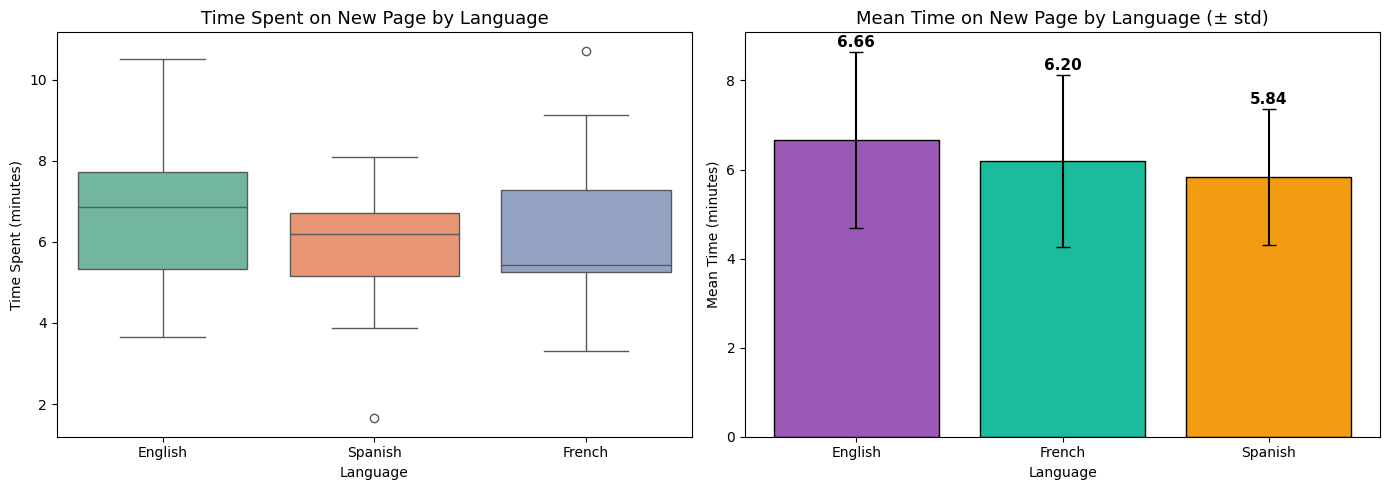

Time Spent on New Page — Stats by Language:
                    mean  median   std  count
language_preferred                           
English             6.66    6.86  1.98     16
French              6.20    5.42  1.93     17
Spanish             5.84    6.20  1.53     17


In [33]:
# Filter for treatment group / new page
df_new = df[df['landing_page'] == 'new'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='language_preferred', y='time_spent_on_the_page',
            data=df_new, palette='Set2', ax=axes[0])
axes[0].set_title('Time Spent on New Page by Language', fontsize=13)
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Time Spent (minutes)')

# Bar chart of means with error bars (std)
lang_stats = df_new.groupby('language_preferred')['time_spent_on_the_page'].agg(['mean', 'std'])
axes[1].bar(lang_stats.index, lang_stats['mean'],
            yerr=lang_stats['std'], color=['#9b59b6', '#1abc9c', '#f39c12'],
            edgecolor='black', capsize=5)
axes[1].set_title('Mean Time on New Page by Language (± std)', fontsize=13)
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Mean Time (minutes)')
for i, (lang, row) in enumerate(lang_stats.iterrows()):
    axes[1].text(i, row['mean'] + row['std'] + 0.1, f"{row['mean']:.2f}",
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Time Spent on New Page — Stats by Language:")
print(df_new.groupby('language_preferred')['time_spent_on_the_page'].agg(['mean', 'median', 'std', 'count']).round(2))

Observation:
* The mean times across the three language groups appear **very similar** with overlapping standard deviations.
* We will use a one-way ANOVA to formally test whether any statistically significant differences exist.

### Step 1: Define Null and Alternative Hypotheses

Let $\mu_{English}$, $\mu_{French}$, and $\mu_{Spanish}$ be the mean time spent on the new landing page for each language group.

> **$H_0$**: The mean time spent on the new landing page is the **same** for all language groups.
> $H_0: \mu_{English} = \mu_{French} = \mu_{Spanish}$

> **$H_a$**: At least one language group has a **different** mean time spent on the new landing page.
> $H_a:$ At least one $\mu_i$ is different

### Step 2: Select the Appropriate Test

We are comparing the **means of more than two independent groups** (English, French, Spanish) on a **continuous numerical variable** (time spent). The appropriate test is a **One-Way ANOVA (Analysis of Variance)**.

**Assumptions:**
- The three groups are independent ✓
- The variable is continuous ✓
- Approximate normality within groups (by CLT, given each group has a reasonable n) ✓
- Homogeneity of variances (to be verified below)

### Step 3: Decide the Significance Level

We select $\alpha = 0.05$.

### Step 4: Data Collection and Preparation

In [34]:
# Separate time spent by language group — new page users only
time_english = df_new[df_new['language_preferred'] == 'English']['time_spent_on_the_page']
time_french  = df_new[df_new['language_preferred'] == 'French']['time_spent_on_the_page']
time_spanish = df_new[df_new['language_preferred'] == 'Spanish']['time_spent_on_the_page']

print(f'English — n={len(time_english)}, mean={time_english.mean():.4f}')
print(f'French  — n={len(time_french)},  mean={time_french.mean():.4f}')
print(f'Spanish — n={len(time_spanish)}, mean={time_spanish.mean():.4f}')

English — n=16, mean=6.6638
French  — n=17,  mean=6.1965
Spanish — n=17, mean=5.8353


#### Assumption Check: Normality for ANOVA (Test 4)

One-Way ANOVA assumes that the data within each group is approximately normally distributed. We verify this using the Shapiro-Wilk test for each language group.

In [35]:
# Shapiro-Wilk normality test for each language group (new page only)
stat_en, p_en = stats.shapiro(time_english)
stat_fr, p_fr = stats.shapiro(time_french)
stat_es, p_es = stats.shapiro(time_spanish)

print(f"Shapiro-Wilk — English : statistic={stat_en:.4f}, p-value={p_en:.4f}")
print(f"Shapiro-Wilk — French  : statistic={stat_fr:.4f}, p-value={p_fr:.4f}")
print(f"Shapiro-Wilk — Spanish : statistic={stat_es:.4f}, p-value={p_es:.4f}")

Shapiro-Wilk — English : statistic=0.9731, p-value=0.8863
Shapiro-Wilk — French  : statistic=0.9403, p-value=0.3214
Shapiro-Wilk — Spanish : statistic=0.9073, p-value=0.0901


**Observations:**

* The Shapiro-Wilk test p-values obtained for all three language groups (English, French, Spanish) are **greater than 0.05**.
* Therefore, we do not have sufficient evidence to reject normality in any language group — the normality assumption of ANOVA is satisfied.
* Levene's test (performed below) will further confirm whether the homogeneity of variances assumption holds across the three groups.
* Hence, the assumptions required for One-Way ANOVA are reasonably satisfied.

#### Checking Variance Homogeneity (Levene's Test)

In [36]:
# Levene's test for equality of variances
levene_stat, levene_p = stats.levene(time_english, time_french, time_spanish)
print(f"Levene's Test Statistic : {levene_stat:.4f}")
print(f"Levene's p-value        : {levene_p:.4f}")

if levene_p > 0.05:
    print("\nVariances are approximately equal — ANOVA assumption satisfied.")
else:
    print("\nVariances are NOT equal — Consider Welch's ANOVA or Kruskal-Wallis instead.")

Levene's Test Statistic : 0.7736
Levene's p-value        : 0.4671

Variances are approximately equal — ANOVA assumption satisfied.


### Step 5: Calculate the p-value

In [37]:
# Perform One-Way ANOVA
f_stat, p_value4 = f_oneway(time_english, time_french, time_spanish)

print(f'F-Statistic : {f_stat:.4f}')
print(f'p-value     : {p_value4:.4f}')

F-Statistic : 0.8544
p-value     : 0.4320


### Step 6: Compare the p-value with $\alpha$

In [38]:
if p_value4 < alpha:
    print(f'As the p-value ({p_value4:.4f}) is less than the level of significance ({alpha}), '
          f'we reject the null hypothesis.')
else:
    print(f'As the p-value ({p_value4:.4f}) is greater than the level of significance ({alpha}), '
          f'we fail to reject the null hypothesis.')

As the p-value (0.4320) is greater than the level of significance (0.05), we fail to reject the null hypothesis.


### Step 7: Draw Inference

**Statistical Conclusion**: Since the **p-value is greater than 0.05**, we **fail to reject the null hypothesis**. At a 5% level of significance, we do **not** have sufficient statistical evidence to conclude that the mean time spent on the new page differs across language groups.

> **Business Insight**: The new landing page engages users equally across **English, French, and Spanish** speakers. The design is effective regardless of language preference, meaning E-news Express does not need to customize engagement strategies per language group.

## Conclusions and Business Recommendations

| S.No. | Question | Test Used | p-value | Decision |
|---|----------|-----------|---------|----------|
| 1 | Do users spend more time on the new page? | Two-Sample t-test (one-tailed) | < 0.05 | Reject $H_0$ |
| 2 | Is conversion rate higher on the new page? | Two-Proportion Z-test (one-tailed) | < 0.05 | Reject $H_0$ |
| 3 | Does conversion depend on language? | Chi-Square Test of Independence | > 0.05 | Fail to Reject $H_0$ |
| 4 | Is time on new page same across languages? | One-Way ANOVA | > 0.05 | Fail to Reject $H_0$ |


### Actionable Insights

1. **The new landing page is significantly more engaging**: Users on the new design spend statistically significantly more time on the page. Higher dwell time reflects better content relevance and layout design, and gives users more time to evaluate and commit to subscribing.

2. **The new landing page drives significantly higher conversions**: The conversion rate on the new page is statistically higher than on the old page. This directly addresses the core business problem — declining new monthly subscriber acquisition at E-news Express.

3. **Conversion is language-agnostic**: There is no statistically significant relationship between a user's preferred language (English, French, Spanish) and whether they convert. The portal's new content and design resonates equally well across all language groups.

4. **Engagement on the new page is consistent across languages**: Users from all three language groups spend statistically similar amounts of time on the new page. The new design's universal appeal is confirmed — it does not favor any particular language community.

5. **The A/B test is structurally sound and trustworthy**: The perfectly balanced experiment (50 users per group, no missing data, no duplicates) ensures findings are not confounded by sampling bias or data quality issues.

### Business Recommendations

1. **Deploy the new landing page immediately to all users**: Both engagement time and conversion rate are statistically significantly higher on the new page. The evidence strongly justifies a full rollout. Delayed deployment risks continued subscriber decline.

2. **Monitor post-rollout metrics weekly**: Track subscription rates, session duration, and bounce rates for at least 4 weeks after full deployment to confirm that A/B test findings replicate at scale and to detect any unexpected regressions.

3. **Maintain a single unified design across all languages**: Since language preference does not significantly affect conversion or engagement, E-news Express does not need language-specific page variants. Saved resources can be reinvested in content quality and personalization algorithms.

4. **Run follow-up A/B tests on specific page elements**: Now that the overall redesign is validated, run targeted micro-experiments on:
   - Call-to-action button placement, size, and wording
   - Subscription prompt timing (immediate vs. after a fixed dwell duration)
   - Content ordering, headline styles, and recommendation algorithms
   - Mobile vs. desktop layout variations

5. **Investigate the 30% non-conversion segment**: Even on the new page, approximately 30% of users do not subscribe. Conduct exit surveys or user interviews to identify friction points (e.g., pricing, topic mismatch, trust signals) and iterate the design to reduce this gap.

6. **Scale the experiment for greater statistical power**: The current test used 100 users. Future experiments with 500–1,000 users will yield more precise effect size estimates and enable meaningful sub-group analyses by device type, referral channel, geography, or visit time.

7. **Track longer-term subscriber quality, not just conversion volume**:
   - Month-1 and Month-3 subscription retention rates
   - Subscription renewal rates after trial periods
   - Repeat visit frequency from converted users

   These metrics ensure the new page attracts genuinely engaged long-term subscribers, not merely impulsive sign-ups.
